In [1]:
!pip3 install google-auth dotenv

In [2]:
import os 
import glob
import time
import json
import numpy as np
# import ssl
# import urllib.request
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from astropy.io import fits
from google import genai 
from google.oauth2 import service_account

In [3]:
load_dotenv(dotenv_path = ".env")
key_path = os.getenv("GCP_SERVICE_ACCOUNT_FILE")
project_id = os.getenv("GCP_PROJECT_ID")
# Define the correct scope for Vertex AI
scopes = ["https://www.googleapis.com/auth/cloud-platform"]

# Explicitly build the credentials object with the required scope
credentials = service_account.Credentials.from_service_account_file(key_path, scopes = scopes)

# This didn't work as the code didn't automatically recognize the environment 
# os.environ['GOOGLE_CREDIDENTIALS'] = 'gen-lang-client-0525525309-493c9e210b3b.json'

# Create a Gemini Client 
client = genai.Client(vertexai = True, project = project_id, location = "us-central1", credentials = credentials)

In [4]:
# Grab all files
fits_files = glob.glob("**/*.fits", recursive = True)
print(f"Found {len(fits_files)} amount of files")

Found 50 amount of files


In [5]:
# Create a dictionary of Gemini under investigation
models = {
    "Gemini Flash": "gemini-2.5-flash",
    "Gemini Pro": "gemini-2.5-pro"
}
# The two metric parameters that will be used on a graph for measurable results
performance_metrics = {
    model_label : {
        "times": [],
        "accuracies": []
    } 
    for model_label in models 
}
# Start the loop
for model_label, model_id in models.items():
    print(f"Testing {model_label}...")
    for i, file_path in enumerate(fits_files):
        correct = 0
        with fits.open(file_path) as hdul:
            header = hdul[0].header
            header_text = repr(header)
            # Get ground truths using astropy library 
            ground_truths = {    
                "TARGNAME" : str(header.get("TARGNAME", "UNKNOWN")).strip(),
                "INSTRUME" : str(header.get("INSTRUME", "UNKNOWN")).strip(),
                "FILTER" : str(header.get("FILTER", "UNKNOWN")).strip()
            }
            # Ask the Client to extract those parameters
            prompt = f"""
            Act as an expert astrophysics data processing agent.
            Below is a raw, unformatted metadata text header from a JWST FITS file.
        
            Extract the following 3 parameters and return them strictly as a valid JSON object:
            1. "TARGNAME" (Target Name)
            2. "INSTRUME" (Instrument used)
            3. "FILTER" (Filter used)
            
            Do not write markdown formatting block tags (like ```json). Just return the raw JSON string.
            Header:
            {header_text}
            
            """
            # Measure time consumption 
            start_time = time.time()
            try:
                response = client.models.generate_content(model = model_id, contents = prompt)
                latency = time.time() - start_time
                
                # Clean up any unsorted formatting blocktags if the Client outputs them 
                corrected_data = response.text.replace("```json", "").replace("```", "").strip()
                extracted_data = json.loads(corrected_data)
                
                # Measure whether the Client's output matches the actual values
                for parameter in ["TARGNAME", "INSTRUME", "FILTER"]:
                    if str(extracted_data.get(parameter, "")).strip().upper() == ground_truths[parameter].strip().upper():
                        correct += 1
                accuracy = (correct / 3.0) * 100.0
            except Exception as e:
                # If an API error, rate limit, or JSON parsing error occurs
                latency = time.time() - start_time
                accuracy = 0.0
                print(f"Error processing file {i+1} with {model_label}: {e}")
            # Save metrics
            performance_metrics[model_label]["times"].append(latency)
            performance_metrics[model_label]["accuracies"].append(accuracy)
            print(f"[{model_label}]File {i+1:02d}/{len(fits_files):02d} | Time: {latency:.2f}s | Accuracy: {accuracy:.3f}%")

            # brief pause to respect API rate limit 
            time.sleep(0.2)
print("Benchmark completed")

Testing Gemini Flash...
[Gemini Flash]File 01/50 | Time: 2.96s | Accuracy: 100.000%
[Gemini Flash]File 02/50 | Time: 2.25s | Accuracy: 100.000%
[Gemini Flash]File 03/50 | Time: 1.62s | Accuracy: 100.000%
[Gemini Flash]File 04/50 | Time: 1.97s | Accuracy: 100.000%
[Gemini Flash]File 05/50 | Time: 1.75s | Accuracy: 100.000%
[Gemini Flash]File 06/50 | Time: 1.62s | Accuracy: 100.000%
[Gemini Flash]File 07/50 | Time: 1.93s | Accuracy: 100.000%
[Gemini Flash]File 08/50 | Time: 1.73s | Accuracy: 100.000%
[Gemini Flash]File 09/50 | Time: 1.95s | Accuracy: 100.000%
[Gemini Flash]File 10/50 | Time: 1.52s | Accuracy: 100.000%
[Gemini Flash]File 11/50 | Time: 2.18s | Accuracy: 100.000%
[Gemini Flash]File 12/50 | Time: 1.50s | Accuracy: 100.000%
[Gemini Flash]File 13/50 | Time: 1.72s | Accuracy: 100.000%
[Gemini Flash]File 14/50 | Time: 1.30s | Accuracy: 100.000%
[Gemini Flash]File 15/50 | Time: 2.22s | Accuracy: 100.000%
[Gemini Flash]File 16/50 | Time: 1.47s | Accuracy: 100.000%
[Gemini Flash]Fi

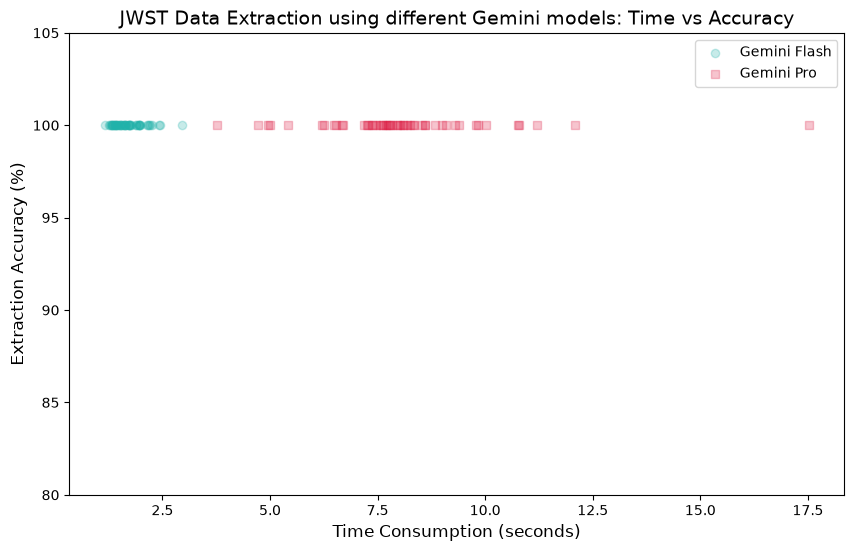

In [6]:
# Begin plotting the results using matplotlib 
plt.figure(figsize = (10, 6))

markers = {"Gemini Flash": "o", "Gemini Pro": "s"}
colors = {"Gemini Flash": "lightseagreen", "Gemini Pro": "crimson"}
for model_label in models:
    times = performance_metrics[model_label]["times"]
    accuracies = performance_metrics[model_label]["accuracies"]
    plt.scatter(times, accuracies, color = colors[model_label], label = model_label, alpha = 0.25, marker = markers[model_label])
plt.title("JWST Data Extraction using different Gemini models: Time vs Accuracy", fontsize = 14)
plt.xlabel("Time Consumption (seconds)", fontsize = 12)
plt.ylabel("Extraction Accuracy (%)", fontsize = 12)
plt.ylim(80, 105)
plt.legend()
plt.show()

In [8]:
# THIS IS A SAMPLE TEST RUN WITHOUT DEPLOYING TIME AND ACCURACY STAMPS 


if len(fits_files) > 0:
    sample_file = fits_files[0]
    print(f"\nOpening sample file: {sample_file}")
    with fits.open(sample_file) as hdul:
        primary_header = hdul[0].header
        header_text = repr(primary_header)
    prompt = f"""
    Act as an expert astrophysics data processing agent.
    Below is a raw, unformatted metadata text header from a JWST FITS file.

    Extract the following 3 aspects and return them strictly as a valid JSON object:
    1. "TARGNAME" (Target Name)
    2. "INSTRUME" (Instrument used)
    3. "FILTER" (Filter used)
    
    Do not write markdown formatting block tags (like ```json). Just return the raw JSON string.
    Header:
    {header_text}
    
    """
    print("Sending request to Gemini...")

    response = client.models.generate_content(model = "gemini-2.5-flash", contents = prompt)

    
    # print(header_text[:500])

    # print("Target Name:", primary_header.get("TARGNAME"))
    # print("Instrument :", primary_header.get("INSTRUME"))
    # print("Filter Used:", primary_header.get("FILTER"))
else:
    print("No FITS files detected.")


Opening sample file: MAST_2026-07-15T1442/MAST_2026-07-15T1442/JWST/jw02731001001_02101_00001_nrcb2_o001_crf.fits
Sending request to Gemini...


In [10]:
# create a web_assets directory 
os.makedirs("web_assets", exist_ok = True)

# Official NASA images for later side-by-side comparison in the app
# ssl._create_default_https_context = ssl._create_unverified_context

# composite_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/8/87/JWST_2022-07-12_Carina_Nebula.png/1200px-JWST_2022-07-12_Carina_Nebula.png"
# save_path = "web_assets/carina_composite.jpg"

# if not os.path.exists(save_path):
#     print("Downloading official NASA composite image...")
#     urllib.request.urlretrieve(composite_url, save_path)
#     print("Saved to web_assets/carina_composite.jpg!")
# PS: didn't work

# pick a sample FITS file to showcase on the dashboard
# sample_file = fits_files[0]

all_metadata = []

# Expanded to include all
sample_files = fits_files

for i, file_path in enumerate(sample_files):
    file_name = os.path.basename(file_path)

    # generate unique image file name for each iteration
    image_file_name = f"target_image_{i+1}.png"
    image_save_path = os.path.join("web_assets", image_file_name)
    
    with fits.open(file_path) as hdul:
        # extract and save 2D image
        image_data = None
        for hdu in hdul:
            if hdu.data is not None and len(hdu.data.shape) >= 2:
                image_data = hdu.data
                break

        if image_data is not None:
            if len(image_data.shape) > 2:
                image_data = image_data[0]
            
            # 1. Percentile contrast stretching to reveal faint gas & dust
            vmin = np.percentile(image_data, 1)      # Ignore dark space noise
            vmax = np.percentile(image_data, 99.5)   # Prevent bright stars from blowing out
        
            # 2. Render with contrast scaling and vibrant space colormap ('magma' or 'plasma')
            plt.figure(figsize=(6, 6))
            plt.imshow(image_data, cmap="magma", origin="lower", vmin=vmin, vmax=vmax)
            plt.axis("off")
            plt.savefig(image_save_path, bbox_inches="tight", pad_inches=0.1, dpi=150)
            plt.close()
            
        # extract telemetry data header with gemini flash
        header = hdul[0].header
        header_text = repr(header)

        # prompt Gemini Flash for the metadata
        prompt = f"""
        Act as an expert astrophysics data processing agent.
        Below is a raw, unformatted metadata text header from a James Webb Space Telescope's FITS file. 
    
        Extract the following 3 parameters and return them strictly as a valid JSON object:
        1. "TARGNAME" (Target Name)
        2. "INSTRUME" (Instrument used)
        3. "FILTER" (Filter used)
    
        Do not write markdown formatting block tags (like ```json). Just return the raw JSON string. 
        Header: 
        {header_text}
        """
        try:
            response = client.models.generate_content(model = "gemini-2.5-flash", contents = prompt)
        
            # clean up formatting block tags if present 
            corrected_data = response.text.replace("```json", "").replace("```", "").strip()
            extracted_metadata = json.loads(corrected_data)
        except Exception as e:
            print(f"Error on file {file_name}: {e}")
            extracted_data = {}

    # build record 
    target = extracted_metadata.get("TARGNAME", "Unknown")
    instrument = extracted_metadata.get("INSTRUME", "Unknown")
    filter_used = extracted_metadata.get("FILTER", "Unknown")

    record = {
        "TARGNAME": target,
        "INSTRUME": instrument,
        "FILTER": filter_used,
        "FILE_NAME": file_name,
        "IMAGE_PATH": f"web_assets/{image_file_name}"
    }
    # # add image reference path into the JSON metadata for the webpage to read
    # extracted_metadata["IMAGE_PATH"] = "web_assets/target_image.png"
    # extracted_metadata["FILE_NAME"] = os.path.basename(sample_file)
    all_metadata.append(record)
    print(f"[{i+1} / {len(sample_files)}] Processed {file_name} -> Target: {target}")
    
    time.sleep(0.2)
# save the metadata as a JSON file for the website
with open("web_assets/data.json", "w") as f:
    json.dump(all_metadata, f, indent = 4)

print("\nSaved metadata to web_assets/data.json:\n")
print(json.dumps(all_metadata, indent = 4))

      

[1 / 50] Processed jw02731001001_02101_00001_nrcb2_o001_crf.fits -> Target: NGC 3324
[2 / 50] Processed jw02731001001_02101_00004_nrcb1_o001_crf.fits -> Target: NGC 3324
[3 / 50] Processed jw02731001001_02101_00003_nrcb2_o001_crf.fits -> Target: NGC 3324
[4 / 50] Processed jw02731001001_02101_00002_nrcb2_o001_crf.fits -> Target: NGC 3324
[5 / 50] Processed jw02731001001_02101_00005_nrcb1_o001_crf.fits -> Target: NGC 3324
[6 / 50] Processed jw02731001001_02101_00003_nrcb1_o001_crf.fits -> Target: NGC 3324
[7 / 50] Processed jw02731001001_02101_00004_nrcb2_o001_crf.fits -> Target: NGC 3324
[8 / 50] Processed jw02731001001_02101_00005_nrcb2_o001_crf.fits -> Target: NGC 3324
[9 / 50] Processed jw02731001001_02101_00002_nrcb1_o001_crf.fits -> Target: NGC 3324
[10 / 50] Processed jw02731001001_02101_00001_nrcb1_o001_crf.fits -> Target: NGC 3324
[11 / 50] Processed jw02731001001_02101_00001_nrca2_o001_crf.fits -> Target: NGC 3324
[12 / 50] Processed jw02731001001_02101_00002_nrca2_o001_crf.fi

In [11]:
%%html
<div style="background-color: #02273b; padding: 15px; border-radius: 5px;">
    <h2 style = "color: #6382c4;">Future Upgrades</h2>
    <p style = "color: #D7F5FC;">My next step was to implement a side-by-side comparison 
between the images processed by the client in 
matplotlib with actual NASA images of that
same celestial object/region. Uploading directly from
NASA or Wikimedia didn't work because of a certificate
error. In the future, I could look into each image's path
and manually download the images online. The URL to each
FITS file includes all the necessary infromation to
find the specific region, position, camera, etc. 
(see https://jwst-pipeline.readthedocs.io/en/latest/jwst/data_products/file_naming.html
for exact filename control).</p>
</div>
